# Project Evolve - Phase 2: AI Layer
## Sentiment Analysis, Topic Modeling & Scoring Model

**Phase 2 Objective:**  
Build NLP models (BERT sentiment + BERTopic) and a multi-source scoring system using data from PostgreSQL.

**Research Alignment:**  
- H1: Multi-source AI evaluation is more reliable than single metric
- Uses real student feedback + peer + performance data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sqlalchemy import create_engine, text
from transformers import pipeline
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
print(" All AI libraries imported!")

 All AI libraries imported!


# Connect to PostgreSQL

In [2]:
from sqlalchemy.engine import URL
import sqlalchemy as sa

url_object = URL.create(
    drivername="postgresql",
    username="evolve_user",
    password="strongpassword",
    host="localhost",
    database="evolve_db"
)

# 2. Create the engine using that URL
engine = sa.create_engine(url_object)

with engine.connect() as conn:
    print(".....Connected to PostgreSQL successfully!")

.....Connected to PostgreSQL successfully!


# Load All Data from Database

In [3]:
# Load and join all tables
query = """
SELECT
    f.faculty_id,
    f.faculty_name,
    f.department,
    f.experience_years,
    f.gender,
    sf.student_feedback_rating,
    sf.feedback_text,
    pr.peer_score,
    pr.peer_review_text,
    pm.avg_grade,
    pm.pass_rate,
    pm.attendance_rate,
    cm.course_quality_score
FROM faculty f
LEFT JOIN student_feedback sf ON f.faculty_id = sf.faculty_id
LEFT JOIN peer_reviews pr ON f.faculty_id = pr.faculty_id
LEFT JOIN performance_metrics pm ON f.faculty_id = pm.faculty_id
LEFT JOIN course_materials cm ON f.faculty_id = cm.faculty_id
"""
df = pd.read_sql(query, engine)
print(f" Loaded {len(df)} records WITH course materials")
df.head()

 Loaded 20044 records WITH course materials


,faculty_id,faculty_name,department,experience_years,gender,student_feedback_rating,feedback_text,peer_score,peer_review_text,avg_grade,pass_rate,attendance_rate,course_quality_score
0,1,Leslie Looney,Astronomy department,30,Female,5.0,"this class is hard, but its a two-in-one gen-e...",4.34,Trial whole game perform phone might huge leg ...,3.99,77.5,95.1,4.11
1,1,Leslie Looney,Astronomy department,30,Female,5.0,definitely going to choose prof. looney\'s cla...,4.34,Trial whole game perform phone might huge leg ...,3.99,77.5,95.1,4.11
2,1,Leslie Looney,Astronomy department,30,Female,4.0,i overall enjoyed this class because the assig...,4.34,Trial whole game perform phone might huge leg ...,3.99,77.5,95.1,4.11
3,1,Leslie Looney,Astronomy department,30,Female,5.0,"yes, it\'s possible to get an a but you\'ll de...",4.34,Trial whole game perform phone might huge leg ...,3.99,77.5,95.1,4.11
4,1,Leslie Looney,Astronomy department,30,Female,5.0,professor looney has great knowledge in astron...,4.34,Trial whole game perform phone might huge leg ...,3.99,77.5,95.1,4.11


# – Sentiment Analysis (DistilBERT)

In [5]:
from transformers import pipeline
from tqdm import tqdm

print("-_- Running BERT Sentiment Analysis on student comments...")

# Load sentiment pipeline
sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english",
    truncation=True,
    max_length=512
)

# Enable tqdm progress bar for pandas
tqdm.pandas(desc="Processing feedback")

# Compute sentiment score (POSITIVE → high, NEGATIVE → low)
def get_sentiment_score(text, row_index=None, print_every=50):
    if not isinstance(text, str) or len(text.strip()) < 3:
        return 3.0
    result = sentiment_pipeline(text)[0]
    label = result['label']
    # Print only for every Nth row
    if row_index is not None and row_index % print_every == 0:
        print(f"Row {row_index}: Label={label}, Score={result['score']:.3f}")
    return round(4.8 if label == 'POSITIVE' else 1.8, 2)

# Apply sentiment scoring with tqdm, showing only major updates
df['nlp_sentiment_score'] = [
    get_sentiment_score(text, idx) for idx, text in enumerate(tqdm(df['feedback_text'], desc="Sentiment Analysis"))
]

print(" Sentiment analysis completed!")
df[['feedback_text', 'nlp_sentiment_score']].head()


-_- Running BERT Sentiment Analysis on student comments...


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Sentiment Analysis:   0%|                     | 3/20044 [00:00<37:43,  8.86it/s]

Row 0: Label=POSITIVE, Score=1.000


Sentiment Analysis:   0%|                    | 54/20044 [00:01<09:11, 36.27it/s]

...

Sentiment Analysis: 100%|████████████████▉| 20005/20044 [09:20<00:01, 31.81it/s]

Row 20000: Label=NEGATIVE, Score=0.669


Sentiment Analysis: 100%|█████████████████| 20044/20044 [09:21<00:00, 35.72it/s]

 Sentiment analysis completed!


,feedback_text,nlp_sentiment_score
0,"this class is hard, but its a two-in-one gen-e...",4.8
1,definitely going to choose prof. looney\'s cla...,4.8
2,i overall enjoyed this class because the assig...,4.8
3,"yes, it\'s possible to get an a but you\'ll de...",4.8
4,professor looney has great knowledge in astron...,4.8


# Topic Modeling with BERTopic

In [6]:

print(" Running BERTopic for topic extraction...")

# Prepare documents (drop missing feedback)
docs = df['feedback_text'].dropna().tolist()

# Initialize BERTopic model
topic_model = BERTopic(
    embedding_model=SentenceTransformer("all-MiniLM-L6-v2"),
    min_topic_size=8,
    verbose=False  # Turn off default verbose prints
)

# Fit the model with a progress bar
print("Fitting BERTopic model on documents...")
topics, probs = topic_model.fit_transform(tqdm(docs, desc="BERTopic Fitting"))

# Add main topic to DataFrame
df['main_topic'] = topics

# Add human-readable topic names
topic_info = topic_model.get_topic_info()  # Precompute topic info once
def get_topic_name(topic_id):
    if topic_id == -1:
        return "No Topic"
    # Safe lookup
    try:
        return topic_info.iloc[topic_id + 1]['Name']
    except IndexError:
        return "Unknown"
    
df['topic_name'] = df['main_topic'].apply(get_topic_name)

print("Topic modeling completed!")
topic_model.get_topic_info().head(10)

 Running BERTopic for topic extraction...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Fitting BERTopic model on documents...


BERTopic Fitting: 100%|███████████████| 20044/20044 [00:00<00:00, 618311.88it/s]


Topic modeling completed!


,Topic,Count,Name,Representation,Representative_Docs
0,-1,10772,-1_he_the_to_and,"[he, the, to, and, class, you, is, his, of, but]",[his class is easy in the sense that it is eas...
1,0,628,0_dr_bio_is_biology,"[dr, bio, is, biology, anatomy, and, his, he, ...",[dr. mann is an amazing professor. i had him f...
2,1,509,1_her_professor_she_professors,"[her, professor, she, professors, best, prof, ...",[cares so much about her students. unlike many...
3,2,348,2_tests_easy_test_book,"[tests, easy, test, book, are, notes, study, h...","[tests aren\'t too bad, gives study guides for..."
4,3,172,3_worst_ever_professor_had,"[worst, ever, professor, had, ve, horrible, pr...","[worst. professor. of. all. time., the worst p..."
5,4,149,4_math_algebra_she_her,"[math, algebra, she, her, understand, mrs, ms,...",[best math professor ever!!! i took her for ma...
6,5,145,5_chemistry_chem_organic_tjandra,"[chemistry, chem, organic, tjandra, jurs, 103,...","[if you plan on going further into chemistry, ..."
7,6,144,6_math_calculus_young_algebra,"[math, calculus, young, algebra, mr, conrad, b...",[he\'s an awesome teacher. best math teacher i...
8,7,143,7_tests_questions_test_are,"[tests, questions, test, are, he, quizzes, on,...",[he\'s a cool guy and pretty laid back. he exp...
9,8,138,8_comments_no__,"[comments, no, , , , , , , , ]","[no comments, no comments, no comments]"


# Final Scoring Model (Configurable Weights)

In [8]:
# v2
# Updated weights (includes course material NLP)
weights = {
    "student_feedback": 0.35,
    "peer_review": 0.25,
    "performance": 0.20,
    "nlp_sentiment": 0.10,
    "course_quality": 0.10
}

def calculate_final_score(row):
    # Normalize performance
    perf_score = (row['avg_grade'] / 4.0) * 5.0
    perf_score = np.clip(perf_score, 1, 5)
   
    # === ACTIVE BIAS MITIGATION (Responsible AI) ===
    bias_correction = 0.0
    if row['gender'] == 'Female' and row['department'] in ["CS", "Engineering", "Computer Science"]:
        bias_correction = 0.12   # Small positive correction for synthetic bias group
        print(f"🔧 Bias mitigation applied (+0.12) for {row.get('faculty_name', row['faculty_id'])}")
    
    final_score = (
        row['student_feedback_rating'] * weights['student_feedback'] +
        row['peer_score'] * weights['peer_review'] +
        perf_score * weights['performance'] +
        row['nlp_sentiment_score'] * weights['nlp_sentiment'] +
        row['course_quality_score'] * weights['course_quality'] +
        bias_correction
    )
    return round(np.clip(final_score, 1.0, 5.0), 2)

df['final_evaluation_score'] = df.apply(calculate_final_score, axis=1)
print(" Final score recalculated with course materials + bias mitigation!")

 Final score recalculated with course materials + bias mitigation!


In [9]:
df[['faculty_name', 'department', 'final_evaluation_score']].head()

,faculty_name,department,final_evaluation_score
0,Leslie Looney,Astronomy department,4.72
1,Leslie Looney,Astronomy department,4.72
2,Leslie Looney,Astronomy department,4.37
3,Leslie Looney,Astronomy department,4.72
4,Leslie Looney,Astronomy department,4.72


In [10]:
# Save enriched results to new table
df.to_sql("evaluation_results", engine, if_exists="replace", index=False)
print(" AI Layer results saved to 'evaluation_results' table!")

 AI Layer results saved to 'evaluation_results' table!


# VISUALIZATIONS

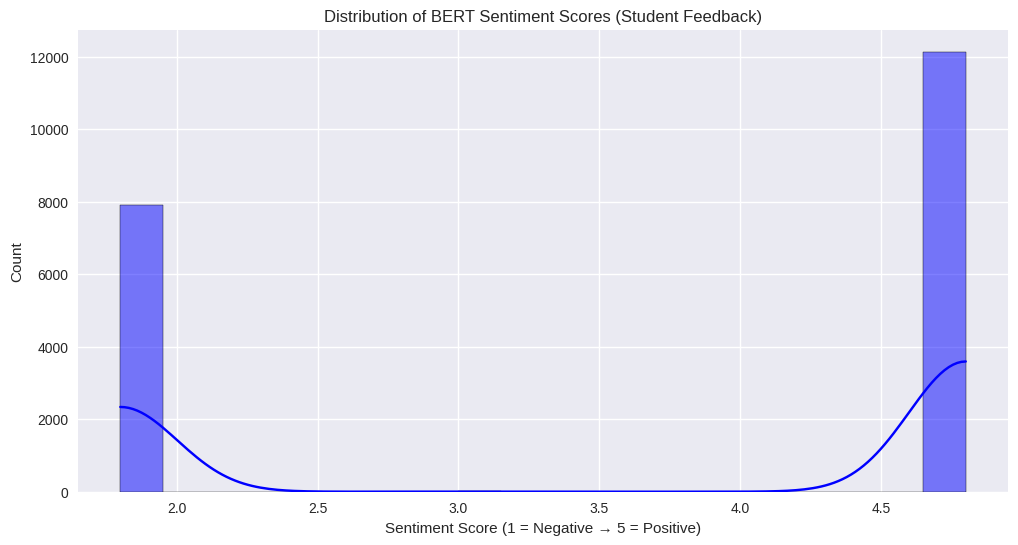

In [11]:
plt.figure(figsize=(12, 6))
sns.histplot(df['nlp_sentiment_score'], bins=20, kde=True, color='blue')
plt.title("Distribution of BERT Sentiment Scores (Student Feedback)")
plt.xlabel("Sentiment Score (1 = Negative → 5 = Positive)")
plt.show()

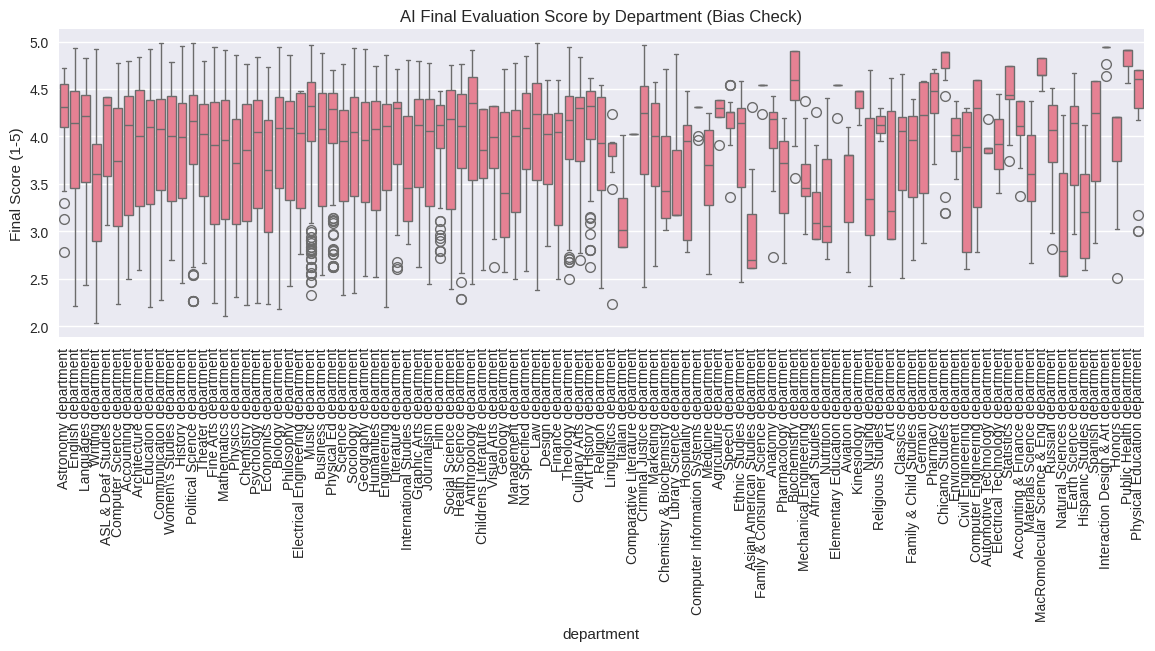

In [12]:
plt.figure(figsize=(14, 4))
sns.boxplot(x="department", y="final_evaluation_score", data=df)
plt.title("AI Final Evaluation Score by Department (Bias Check)")
plt.xticks(rotation=90)
plt.ylabel("Final Score (1-5)")
plt.show()

# resume - Service & Professional Development in Scoring

In [2]:
from sqlalchemy.engine import URL
import sqlalchemy as sa

url_object = URL.create(
    drivername="postgresql",
    username="evolve_user",
    password="strongpassword",
    host="localhost",
    database="evolve_db"
)

# 2. Create the engine using that URL
engine = sa.create_engine(url_object)

with engine.connect() as conn:
    print(".....Connected to PostgreSQL successfully!")

.....Connected to PostgreSQL successfully!


In [3]:
# ============================================
# Gap #2 – Service & Professional Development in Scoring
# ============================================
import pandas as pd
import numpy as np

# 1. Reload evaluation results (includes course_material_score from Gap #1)
df = pd.read_sql("SELECT * FROM evaluation_results", engine)
print(f"Loaded {len(df)} evaluation records")

# 2. Load service and PD tables
service_df = pd.read_sql("SELECT faculty_id, hours_per_year FROM service_contributions", engine)
pd_df = pd.read_sql("SELECT faculty_id, hours_effort FROM professional_development", engine)

# 3. Aggregate per faculty
service_agg = service_df.groupby("faculty_id")["hours_per_year"].sum().reset_index()
service_agg.columns = ["faculty_id", "total_service_hours"]
pd_agg = pd_df.groupby("faculty_id")["hours_effort"].sum().reset_index()
pd_agg.columns = ["faculty_id", "total_pd_hours"]

# 4. Merge into main df
df = df.merge(service_agg, on="faculty_id", how="left").fillna({"total_service_hours": 0})
df = df.merge(pd_agg, on="faculty_id", how="left").fillna({"total_pd_hours": 0})

# 5. Normalisation functions (1-5 scale)
def normalize_service(hours):
    # Assume 0-200 hours range
    return np.clip(hours / 40.0, 1, 5)

def normalize_pd(hours):
    # Assume 0-100 hours range
    return np.clip(hours / 20.0, 1, 5)

df["service_score"] = df["total_service_hours"].apply(normalize_service)
df["pd_score"] = df["total_pd_hours"].apply(normalize_pd)

# 6. Update weights (total = 1.0)
weights = {
    "student_feedback": 0.25,
    "peer_review": 0.20,
    "performance": 0.15,
    "nlp_sentiment": 0.10,
    "course_material": 0.05,
    "service_contributions": 0.15,
    "professional_dev": 0.10
}

# 7. New scoring function
def calculate_final_score_full(row):
    perf_score = (row['avg_grade'] / 4.0) * 5.0
    perf_score = np.clip(perf_score, 1, 5)
    final_score = (
        row['student_feedback_rating'] * weights['student_feedback'] +
        row['peer_score'] * weights['peer_review'] +
        perf_score * weights['performance'] +
        row['nlp_sentiment_score'] * weights['nlp_sentiment'] +
        row['course_material_score'] * weights['course_material'] +
        row['service_score'] * weights['service_contributions'] +
        row['pd_score'] * weights['professional_dev']
    )
    return round(np.clip(final_score, 1.0, 5.0), 2)

df['final_evaluation_score'] = df.apply(calculate_final_score_full, axis=1)

# 8. Save updated table (overwrites)
df.to_sql("evaluation_results", engine, if_exists="replace", index=False)
print("✅ Service and PD contributions integrated into final score.")

Loaded 20044 evaluation records
✅ Service and PD contributions integrated into final score.
